In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
#Load dataset
housing = fetch_california_housing()

In [4]:
data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]=housing.target

In [5]:
#Select one feature
x = data[["AveRooms"]].values
y = data[["Price"]].values

In [6]:
#Split data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42 )

In [7]:
#Feature Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [22]:
w = 0
b = 0
learning_rate = 0.1
epochs = 1000
cost_history = []
# Number of training samples
n = len(x_train_scaled)
for i in range(epochs):
    y_pred = w * x_train_scaled.flatten() + b
    dw = (1 / n) * np.sum((y_pred - y_train.flatten()) * x_train_scaled.flatten())
    db = (1 / n) * np.sum(y_pred - y_train.flatten())
    w = w - learning_rate * dw
    b = b - learning_rate * db
    if i % 100 == 0:
        cost = (1 / (2 * n)) * np.sum((y_pred - y_train.flatten()) ** 2)
        print(f"Epoch {i}, Cost = {cost:.4f}")
        cost_history.append(cost)
y_pred_gd = w * x_test_scaled.flatten() + b

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.6516
Epoch 200, Cost = 0.6516
Epoch 300, Cost = 0.6516
Epoch 400, Cost = 0.6516
Epoch 500, Cost = 0.6516
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


In [11]:
print("Gradient Descent")
print("------------------")
print("Weight:",w)
print("Bias:",b)
print("MSE:",mean_squared_error(y_test,y_pred_gd))
print("R2 Score:",r2_score(y_test,y_pred_gd))

Gradient Descent
------------------
Weight: 0.18323881713491486
Bias: 2.0719469373788737
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


In [13]:
#Normal Equation
x_train_ne = np.c_[np.ones((len(x_train),1)),x_train]
x_test_ne = np.c_[np.ones((len(x_test),1)),x_test]
theta = np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train
y_pred_ne = x_test_ne @ theta

In [15]:
print("Normal Equation")
print("------------------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:",mean_squared_error(y_test,y_pred_ne))
print("R2 Score:",r2_score(y_test,y_pred_ne))

Normal Equation
------------------
Intercept: [1.65476227]
Slope: [0.07675559]
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


In [16]:
#Sort values for smooth regression line
sort_axis=np.argsort(x_test.flatten())
x_sorted=x_test[sort_axis]
y_pred_ne_sorted=y_pred_ne[sort_axis]

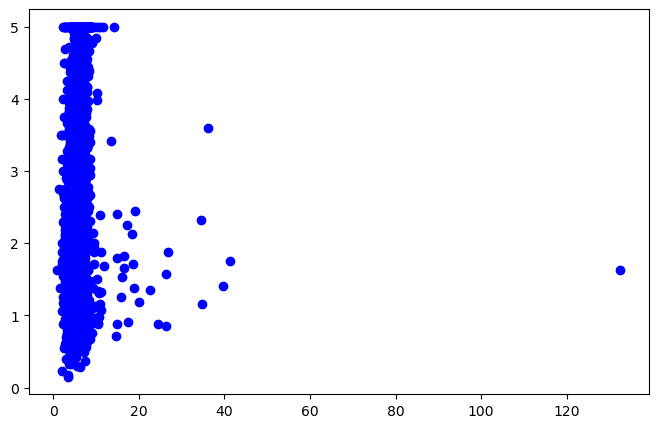

In [18]:
#Regression Line Visualization
#Sort X values for smooth line
index=np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))
#Scatter plot
plt.scatter(x_test,y_test,color='blue',label='Actual Data')

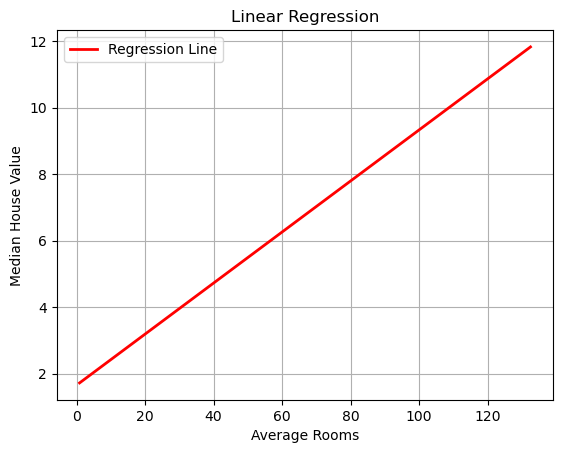

In [19]:
#Regression Line
plt.plot(
    x_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()

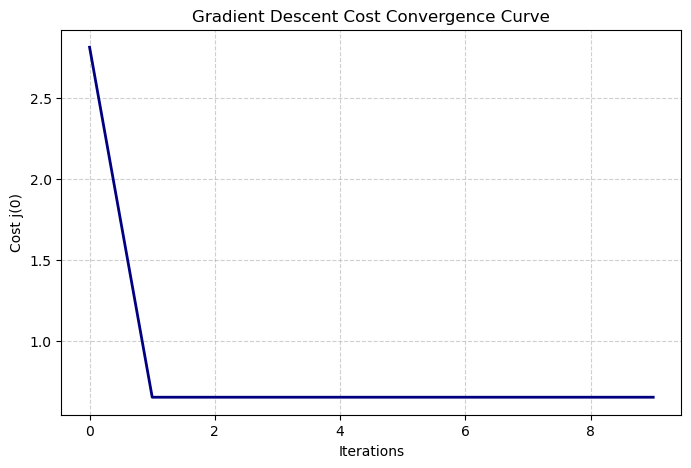

In [23]:
#Cost Convergence Curve
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost j(0)')
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()